# W2 · 真实生物数据表：清洗 + 可视化

**数据来源**：NCBI E-utilities 拉取的 500 条人类 RefSeq mRNA 记录（`w2/data/ncbi_raw.csv`），
另有 60 条记录的 GC 含量（`w2/data/gc_partial.csv`）。

本 notebook 回答三个问题：这份表干不干净？清洗后能看出什么规律？拿哪个数字去讲？

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# 不管从仓库根目录还是 w2/ 里打开，都能找到数据
HERE = Path.cwd()
if not (HERE / "data").exists():
    HERE = HERE / "w2"
DATA, OUT = HERE / "data", HERE / "out"
OUT.mkdir(exist_ok=True)

plt.rcParams["font.family"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 120)

## 1. 先体检：哪里不干净

In [2]:
raw = pd.read_csv(DATA / "ncbi_raw.csv")
print("形状:", raw.shape)
raw.head(3)

形状: (500, 7)


,accession,gene,length,moltype,organism,created,title
0,NM_000077.6,CDKN2A,1191,rna,Homo sapiens,1999/03/19,Homo sapiens cyclin dependent kinase inhibitor...
1,NM_001142769.4,PCDH15,5878,rna,Homo sapiens,2008/12/19,Homo sapiens protocadherin related 15 (PCDH15)...
2,NM_001441094.1,IQSEC2,5112,rna,Homo sapiens,2025/06/04,Homo sapiens IQ motif and Sec7 domain ArfGEF 2...


In [3]:
print("重复 accession:", raw["accession"].duplicated().sum())
print("gene 列带多余文字的:", raw["gene"].str.contains(" ").sum())
print("gene 示例:", raw.loc[raw["gene"].str.contains(" "), "gene"].unique()[:3])
print("moltype 取值:", raw["moltype"].unique())
print("created 是字符串:", repr(raw["created"].iloc[0]))

重复 accession: 0
gene 列带多余文字的: 12
gene 示例: <StringArray>
['ABCC1 blood group']
Length: 1, dtype: str
moltype 取值: <StringArray>
['rna']
Length: 1, dtype: str
created 是字符串: '1999/03/19'


## 2. 清洗

四件事：**gene 规范化**（`ABCC1 blood group` → `ABCC1`）、**日期转真日期**并派生出年份、**去重**、**合并 GC 列**。

In [4]:
df = raw.copy()
df["gene"] = df["gene"].str.split().str[0].str.strip()
df["created"] = pd.to_datetime(df["created"], format="%Y/%m/%d", errors="coerce")
df["year"] = df["created"].dt.year
df = df.drop_duplicates(subset="accession").dropna(subset=["length", "year"])

gc = pd.read_csv(DATA / "gc_partial.csv")
df = df.merge(gc, on="accession", how="left")
print("清洗后:", df.shape, "| 有 GC 的:", df["gc"].notna().sum(), "| 缺 GC 的:", df["gc"].isna().sum())

清洗后: (500, 9) | 有 GC 的: 60 | 缺 GC 的: 440


**缺掉的 GC 不要填 0**：0% GC 在生物学上不可能，填 0 会把均值拉低、也会在图 3 里造出一排假点。
正确做法是——**只对 GC 做分析时用 `dropna()` 取子集**，其余列照常用全量 500 条。

## 3. 三张图

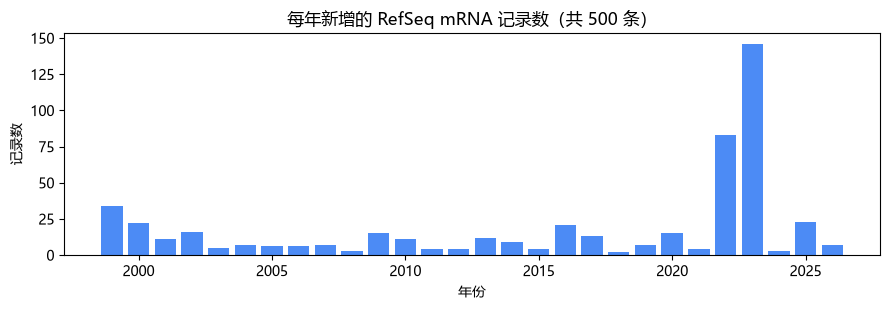

In [5]:
by_year = df["year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(by_year.index, by_year.values, color="#4C8BF5")
ax.set(title=f"每年新增的 RefSeq mRNA 记录数（共 {len(df)} 条）", xlabel="年份", ylabel="记录数")
fig.tight_layout()
fig.savefig(OUT / "fig1_by_year.png", dpi=140)
plt.show()

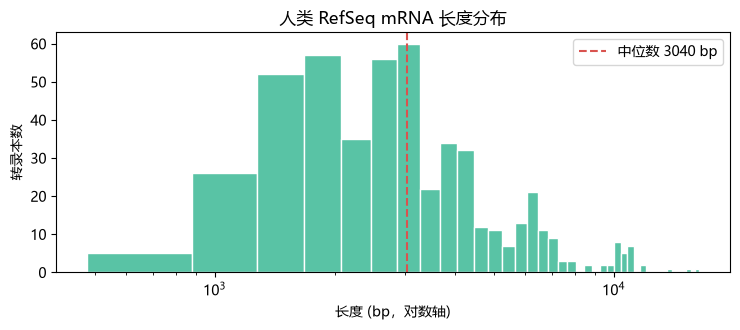

In [6]:
median_len = df["length"].median()

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(df["length"], bins=40, color="#59C3A5", edgecolor="white")
ax.axvline(median_len, color="#D9534F", ls="--", label=f"中位数 {median_len:.0f} bp")
ax.set(xscale="log", title="人类 RefSeq mRNA 长度分布", xlabel="长度 (bp，对数轴)", ylabel="转录本数")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "fig2_length.png", dpi=140)
plt.show()

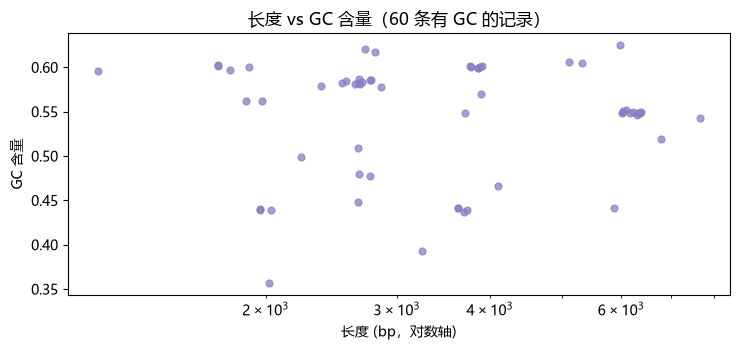

In [7]:
sub = df.dropna(subset=["gc"])

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.scatter(sub["length"], sub["gc"], s=24, alpha=0.75, color="#8E7CC3")
ax.set(xscale="log", title=f"长度 vs GC 含量（{len(sub)} 条有 GC 的记录）",
       xlabel="长度 (bp，对数轴)", ylabel="GC 含量")
fig.tight_layout()
fig.savefig(OUT / "fig3_gc_length.png", dpi=140)
plt.show()

## 4. 拿得出手的数字

In [8]:
print("记录数:", len(df))
print("覆盖基因数:", df["gene"].nunique())
print("长度: 中位 %.0f bp，最短 %d bp，最长 %d bp" % (median_len, df["length"].min(), df["length"].max()))
print("有 GC 的 %d 条: GC 中位 %.1f%%，范围 %.1f%%–%.1f%%"
      % (len(sub), sub["gc"].median() * 100, sub["gc"].min() * 100, sub["gc"].max() * 100))
print("长度与 GC 的相关系数 (log 长度): %.3f" % sub["length"].apply(lambda x: x ** 0.5).corr(sub["gc"]))
print("记录最多的基因:")
print(df["gene"].value_counts().head(5).to_string())

记录数: 500
覆盖基因数: 142
长度: 中位 3040 bp，最短 478 bp，最长 16398 bp
有 GC 的 60 条: GC 中位 55.7%，范围 35.7%–62.5%
长度与 GC 的相关系数 (log 长度): 0.040
记录最多的基因:
gene
ALG8      18
ZBTB35    17
DHCR7     16
ABCC1     12
TENM3     12


### 结论

1. **不清洗就没法按基因统计**：500 条里有 12 行的 `gene` 带着尾缀（如 `ABCC1 blood group`）、日期是字符串、同一基因存在多个转录本；清洗后仍是 500 条，覆盖 **142 个基因**。

2. **记录数在 2022–2023 年集中爆发**（83 + 146 条，占全表 46%）。这不是生物学变化，而是 NCBI 批量重注释的产物 —— 看到异常先怀疑数据来源，别急着讲生物学故事。

3. **长度强烈右偏**：中位 **3040 bp**（478 – 16398 bp），用对数轴才读得出来。

4. **GC 与长度基本无关**：60 条有 GC 的记录中位 **55.7%**（35.7% – 62.5%），与长度的相关系数只有 **0.040**。说明 GC 更像是由基因本身决定的特征，而不是长度的函数。

> 留下的尾巴：GC 只有 60/500 条有值。要拿它做全表结论，得把 500 条序列都拉下来补全（`w2/add_gc.py` 把 60 改掉即可，注意 NCBI 每秒 ≤ 3 次的礼节）。
